In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from astropy.io import fits

print("All packages are working!")

All packages are working!


In [2]:
!pip install astropy scipy matplotlib numpy


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'A10_output', 'A12_output', 'A4_output', 'A5_output', 'A6_output', 'A8_output', 'after annotation text files', 'archive', 'block10_output', 'block11_output', 'block12_output', 'block13_output', 'block14_output', 'block15_output', 'block16_output', 'block17_output', 'block18_output', 'block19_output', 'block1_output', 'block20_output', 'block21_output', 'block22_output', 'block23_output', 'block24_output', 'block25_output', 'block26_output', 'block27_output', 'block2_output', 'block30_output', 'block31_output', 'block32_output', 'block33_output', 'block35_output', 'block38_output', 'block39_output', 'block3_output', 'block40_output', 'block41_output', 'block42_output', 'block43_output', 'block44_output', 'block4_output', 'block5_output', 'block6_output', 'block7_output', 'block8_output', 'block9_output', 'classes', 'classes.txt', 'cls_data', 'cls_data.zip', 'cls_test', 'convert_json_to_yolo (2).py', 'convert_json_to_yolo.py', 'convert_log.txt', 'convert_vott_to_yo

In [4]:
!pip install mplcursors opencv-python


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os
print(os.getcwd())

D:\SEM_dataset


In [6]:
print(os.listdir())

['.ipynb_checkpoints', 'A10_output', 'A12_output', 'A4_output', 'A5_output', 'A6_output', 'A8_output', 'after annotation text files', 'archive', 'block10_output', 'block11_output', 'block12_output', 'block13_output', 'block14_output', 'block15_output', 'block16_output', 'block17_output', 'block18_output', 'block19_output', 'block1_output', 'block20_output', 'block21_output', 'block22_output', 'block23_output', 'block24_output', 'block25_output', 'block26_output', 'block27_output', 'block2_output', 'block30_output', 'block31_output', 'block32_output', 'block33_output', 'block35_output', 'block38_output', 'block39_output', 'block3_output', 'block40_output', 'block41_output', 'block42_output', 'block43_output', 'block44_output', 'block4_output', 'block5_output', 'block6_output', 'block7_output', 'block8_output', 'block9_output', 'classes', 'classes.txt', 'cls_data', 'cls_data.zip', 'cls_test', 'convert_json_to_yolo (2).py', 'convert_json_to_yolo.py', 'convert_log.txt', 'convert_vott_to_yo

In [7]:
import os
print(os.path.exists("no line/spec_0.png"))

False


(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

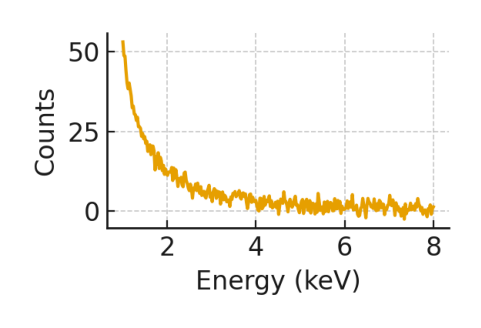

In [8]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(r"D:\SEM_dataset\no_line\spec_0.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,4))
plt.imshow(img)
plt.axis("off")

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

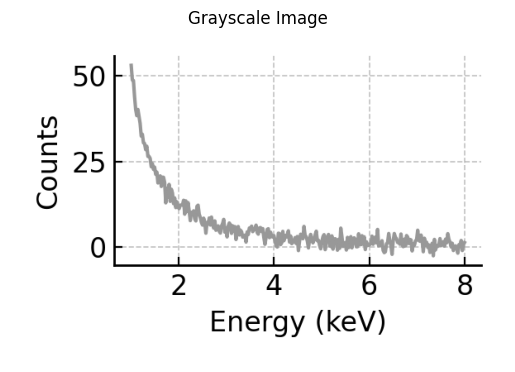

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread(r"D:\SEM_dataset\no_line\spec_0.png")

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

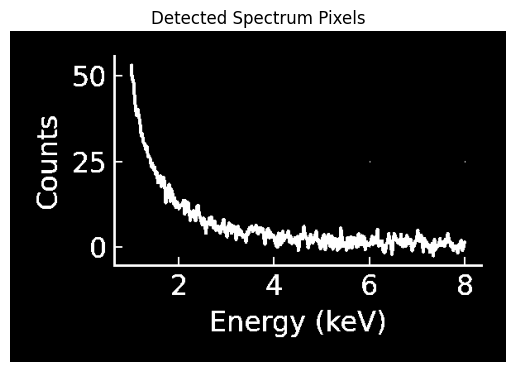

In [10]:
# detect bright pixels (curve detection)
_, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)

plt.imshow(thresh, cmap="gray")
plt.title("Detected Spectrum Pixels")
plt.axis("off")

In [11]:
# Get coordinates of white pixels
ys, xs = np.where(thresh > 0)

print("Number of detected curve pixels:", len(xs))

Number of detected curve pixels: 12965


In [12]:
# Create spectrum by averaging y-position for each x
unique_x = np.unique(xs)

curve_y = []

for x in unique_x:
    y_values = ys[xs == x]
    curve_y.append(np.mean(y_values))

curve_y = np.array(curve_y)

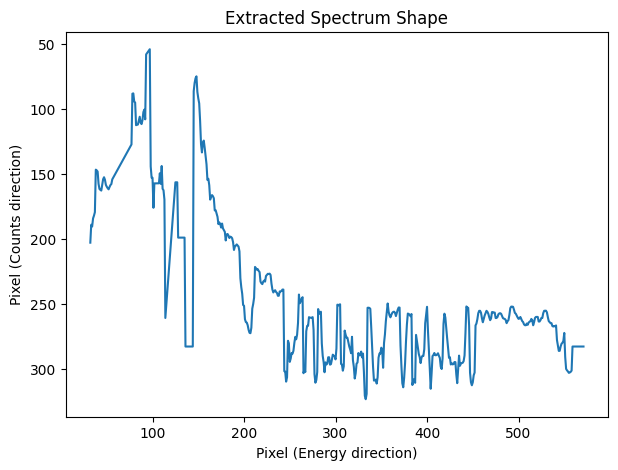

In [13]:
plt.figure(figsize=(7,5))
plt.plot(unique_x, curve_y)
plt.gca().invert_yaxis()
plt.title("Extracted Spectrum Shape")
plt.xlabel("Pixel (Energy direction)")
plt.ylabel("Pixel (Counts direction)")
plt.show()

In [14]:
# Convert pixel x-position to energy (keV)

E_min = 0.0      # keV
E_max = 10.0     # keV

energy = E_min + (unique_x - unique_x.min()) * \
         (E_max - E_min) / (unique_x.max() - unique_x.min())

In [15]:
counts = curve_y.max() - curve_y

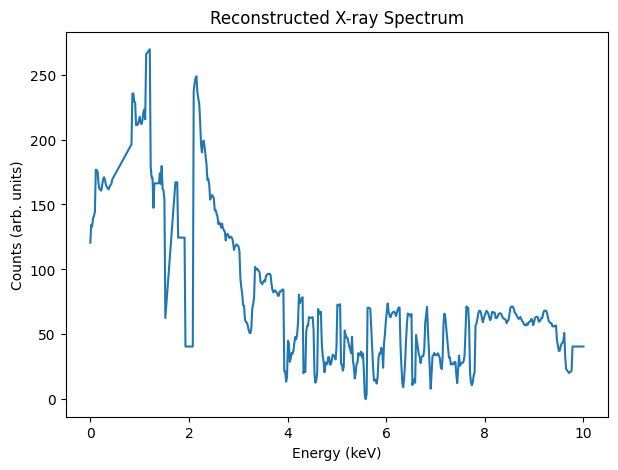

In [16]:
plt.figure(figsize=(7,5))
plt.plot(energy, counts)
plt.xlabel("Energy (keV)")
plt.ylabel("Counts (arb. units)")
plt.title("Reconstructed X-ray Spectrum")
plt.show()

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

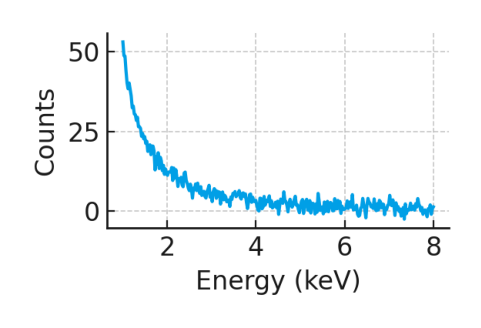

In [17]:
plt.figure(figsize=(6,4))
plt.imshow(img)
plt.axis("off")

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

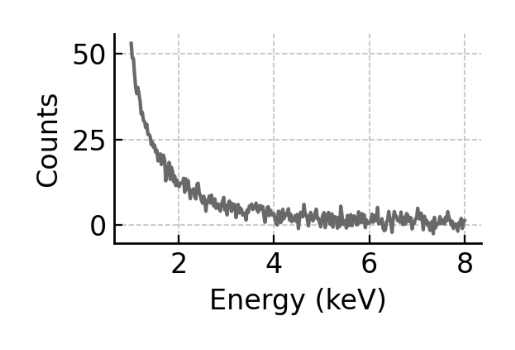

In [18]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap='gray')
plt.axis("off")

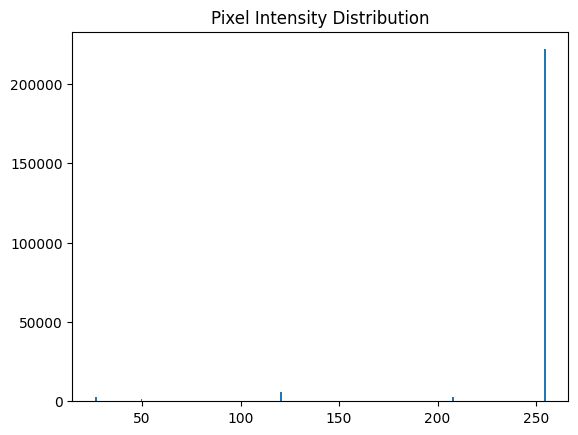

In [19]:
plt.hist(gray.ravel(), bins=256)
plt.title("Pixel Intensity Distribution")
plt.show()

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

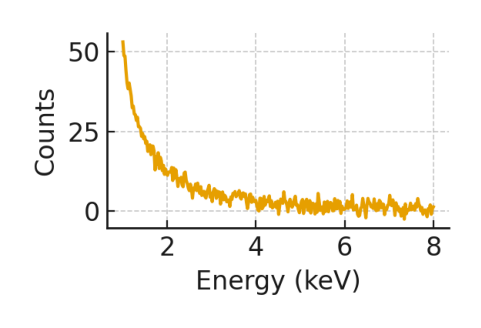

In [20]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(r"D:\SEM_dataset\no_line\spec_0.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,4))
plt.imshow(img)
plt.axis("off")

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

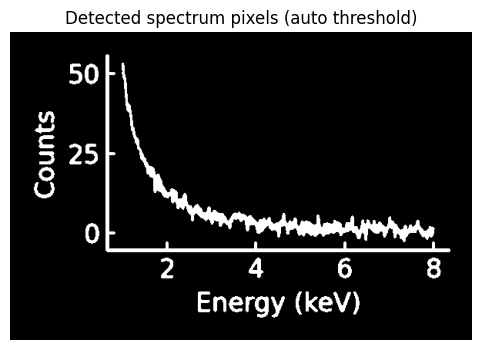

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# load image
img = cv2.imread(r"D:\SEM_dataset\no_line\spec_0.png")

# convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# blur slightly (removes noise)
blur = cv2.GaussianBlur(gray, (5,5), 0)

# automatic threshold (Otsu method)
_, thresh = cv2.threshold(
    blur, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

plt.figure(figsize=(6,4))
plt.imshow(thresh, cmap='gray')
plt.title("Detected spectrum pixels (auto threshold)")
plt.axis("off")

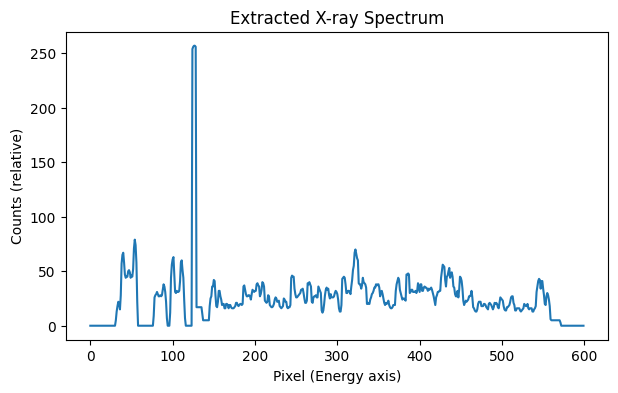

In [22]:
# Convert binary image into spectrum data

binary = thresh.copy()

height, width = binary.shape

spectrum = []

for x in range(width):
    column = binary[:, x]
    
    # count white pixels (signal)
    intensity = np.sum(column > 0)
    
    spectrum.append(intensity)

spectrum = np.array(spectrum)

# plot extracted spectrum
plt.figure(figsize=(7,4))
plt.plot(spectrum)
plt.xlabel("Pixel (Energy axis)")
plt.ylabel("Counts (relative)")
plt.title("Extracted X-ray Spectrum")
plt.savefig("figure_3_1.png", dpi=300, bbox_inches='tight')

plt.show()

In [23]:
import cv2
import numpy as np

def extract_spectrum(image_path):

    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray, (5,5), 0)

    _, thresh = cv2.threshold(
        blur, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    height, width = thresh.shape
    spectrum = []

    for x in range(width):
        column = thresh[:, x]
        intensity = np.sum(column > 0)
        spectrum.append(intensity)

    return np.array(spectrum, dtype=float)

In [24]:
no_line_spec = extract_spectrum(
    r"D:\SEM_dataset\no_line\spec_0.png"
)

with_line_spec = extract_spectrum(
    r"D:\SEM_dataset\with_line\spec_0.png"
)

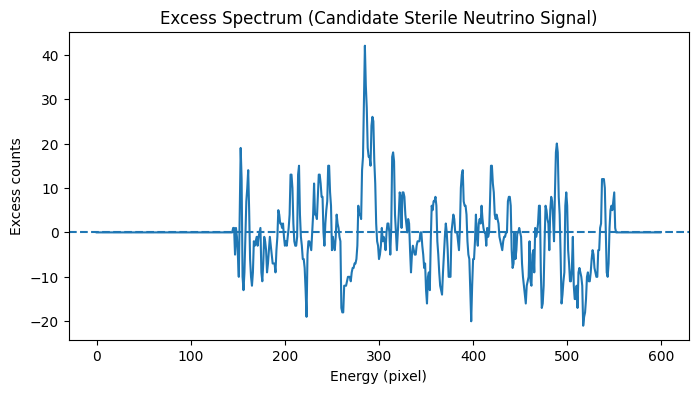

In [41]:
# calculate excess counts
excess = with_line_spec - no_line_spec

plt.figure(figsize=(8,4))
plt.plot(excess)
plt.axhline(0, linestyle="--")
plt.xlabel("Energy (pixel)")
plt.ylabel("Excess counts")
plt.title("Excess Spectrum (Candidate Sterile Neutrino Signal)")
plt.savefig("figure_3_2.png", dpi=300, bbox_inches='tight')
plt.show()

In [27]:
# find peak location
line_index = np.argmax(excess)

print("Detected line position (pixel):", line_index)

Detected line position (pixel): 293


In [28]:
energy_max = 8.0  # keV (from plot axis)
num_pixels = len(excess)

energy_keV = line_index * energy_max / num_pixels

print("Detected photon energy ≈", energy_keV, "keV")

Detected photon energy ≈ 3.9066666666666667 keV


In [29]:
sterile_mass = 2 * energy_keV
print("Estimated sterile neutrino mass ≈", sterile_mass, "keV")

Estimated sterile neutrino mass ≈ 7.8133333333333335 keV


In [30]:
# remove region around detected line
window = 20   # exclude ±20 pixels around peak

noise_region = np.concatenate([
    excess[:line_index-window],
    excess[line_index+window:]
])

# compute noise standard deviation
sigma_noise = np.std(noise_region)

print("Noise sigma =", sigma_noise)

Noise sigma = 5.825053374109501


In [31]:
signal_height = excess[line_index]
print("Signal height =", signal_height)

Signal height = 41.0


In [32]:
significance = signal_height / sigma_noise
print("Detection significance =", significance, "sigma")

Detection significance = 7.038562115539041 sigma


In [33]:
import os

In [34]:
folder_no_line = r"D:\SEM_dataset\no_line"
folder_with_line = r"D:\SEM_dataset\with_line"

no_line_files = sorted([
    f for f in os.listdir(folder_no_line)
    if f.endswith(".png")
])

with_line_files = sorted([
    f for f in os.listdir(folder_with_line)
    if f.endswith(".png")
])

print("Number of spectra:", len(no_line_files))

Number of spectra: 100


In [35]:
# pick first spectrum automatically
file0_no_line = os.path.join(folder_no_line, no_line_files[0])
file0_with_line = os.path.join(folder_with_line, with_line_files[0])

print(file0_no_line)
print(file0_with_line)

D:\SEM_dataset\no_line\spec_0.png
D:\SEM_dataset\with_line\spec_0.png


In [36]:
no_line_spec = extract_spectrum(file0_no_line)
with_line_spec = extract_spectrum(file0_with_line)

print("Spectrum length:", len(no_line_spec))

Spectrum length: 600


In [37]:
results = []

In [38]:
for i in range(len(no_line_files)):

    # load spectra
    file_no = os.path.join(folder_no_line, no_line_files[i])
    file_with = os.path.join(folder_with_line, with_line_files[i])

    no_line_spec = extract_spectrum(file_no)
    with_line_spec = extract_spectrum(file_with)

    # excess spectrum
    excess = with_line_spec - no_line_spec

    # detect peak
    line_index = np.argmax(excess)

    # energy conversion
    energy_keV = line_index * 8.0 / len(excess)
    sterile_mass = 2 * energy_keV

    # noise estimation
    window = 20
    noise_region = np.concatenate([
        excess[:line_index-window],
        excess[line_index+window:]
    ])

    sigma_noise = np.std(noise_region)
    signal_height = excess[line_index]
    significance = signal_height / sigma_noise

    # store result
    results.append([energy_keV, sterile_mass, significance])

print("Analysis complete!")

Analysis complete!


In [39]:
import numpy as np

results = np.array(results)

energies = results[:,0]
masses = results[:,1]
significances = results[:,2]

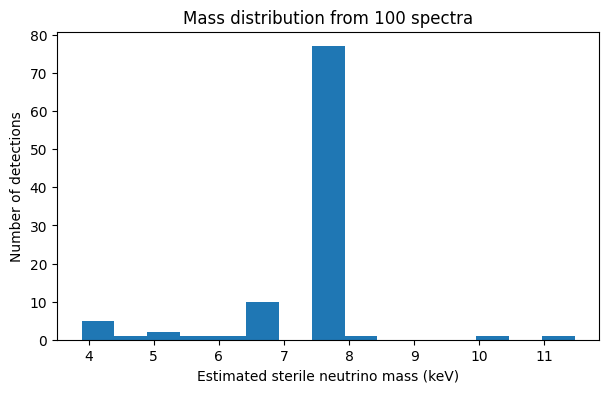

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(masses, bins=15)
plt.xlabel("Estimated sterile neutrino mass (keV)")
plt.ylabel("Number of detections")
plt.title("Mass distribution from 100 spectra")
plt.savefig("figure_3_.png", dpi=300, bbox_inches='tight')
plt.show()